In [1]:
# This project analyzes student performance using machine learning algorithms


In [2]:
import numpy as np
import pandas as pd

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/adilshamim8/student-performance-and-learning-style/student_performance.csv


In [4]:
import pandas as pd

data = pd.read_csv('/kaggle/input/datasets/adilshamim8/student-performance-and-learning-style/student_performance.csv')
data.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [5]:
data.columns


Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle',
       'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore',
       'EduTech', 'StressLevel', 'FinalGrade'],
      dtype='object')

In [6]:
data = data.dropna()

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

In [8]:
X = data.drop('FinalGrade', axis=1)
y = data['FinalGrade']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
X_train_dt = X_train.copy()
X_test_dt = X_test.copy()

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [13]:
y_pred_dt = dt.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       709
           1       1.00      1.00      1.00       703
           2       1.00      1.00      1.00       741
           3       1.00      1.00      1.00       648

    accuracy                           1.00      2801
   macro avg       1.00      1.00      1.00      2801
weighted avg       1.00      1.00      1.00      2801



In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [17]:
y_pred_knn = knn.predict(X_test)

In [18]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7033202427704391
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       709
           1       0.61      0.58      0.59       703
           2       0.65      0.68      0.66       741
           3       0.85      0.71      0.78       648

    accuracy                           0.70      2801
   macro avg       0.71      0.70      0.70      2801
weighted avg       0.71      0.70      0.70      2801



In [19]:
from sklearn.naive_bayes import GaussianNB

In [20]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9982149232416994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       709
           1       1.00      1.00      1.00       703
           2       0.99      1.00      1.00       741
           3       1.00      0.99      1.00       648

    accuracy                           1.00      2801
   macro avg       1.00      1.00      1.00      2801
weighted avg       1.00      1.00      1.00      2801



In [21]:
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))

Decision Tree: 1.0
KNN: 0.7033202427704391
Naive Bayes: 0.9982149232416994


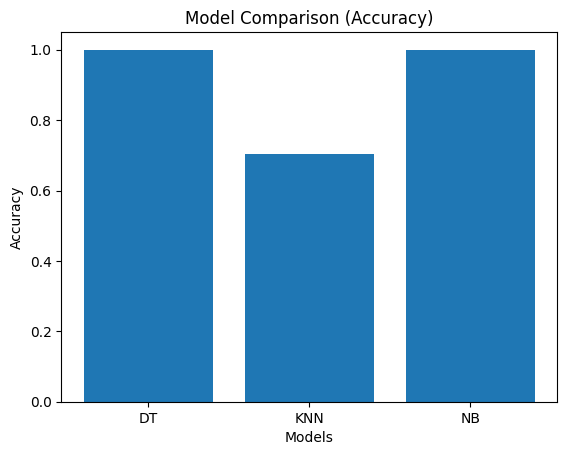

In [22]:
import matplotlib.pyplot as plt

models = ['DT', 'KNN', 'NB']
scores = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_nb)
]

plt.bar(models, scores)
plt.title("Model Comparison (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [23]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_knn))

[[596 105   8   0]
 [197 406  97   3]
 [ 20 140 505  76]
 [  0  14 171 463]]


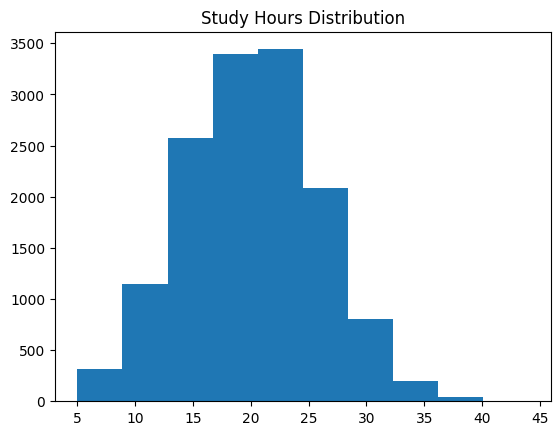

In [24]:
import matplotlib.pyplot as plt

plt.hist(data['StudyHours'])
plt.title("Study Hours Distribution")
plt.show()

In [25]:
# Conclusion

"""
In this project, we applied three machine learning algorithms:
Decision Tree, KNN, and Naive Bayes to predict student performance.

After comparing the models, we found that the best performing model was naive byas based on accuracy.

This shows that machine learning can be used to predict student performance effectively.
"""

'\nIn this project, we applied three machine learning algorithms:\nDecision Tree, KNN, and Naive Bayes to predict student performance.\n\nAfter comparing the models, we found that the best performing model was naive byas based on accuracy.\n\nThis shows that machine learning can be used to predict student performance effectively.\n'